# Error Analysis

This notebook will be used to perform data alaysis of prediction errors. 
- Which attribute types had more errors/correct predictions?
    - Per model and template?

## Prompt-Selection 

### Strict Metrics Evaluate

#### Portuguese

In [180]:
# enable autoreload so imported modules refresh automatically after installs/edits
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
# !uv add matplotlib

In [182]:
import pandas as pd
import matplotlib.pyplot as plt

In [183]:
raw_results_analysis =pd.read_csv("../results/prompt_selection/portuguese/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_1,cls,GNR,Org,Org,tp,NaN
1,gemini,participants,lusa_1,cls,estabelecimento de bebidas,Fac,Fac,tp,NaN
2,gemini,participants,lusa_1,cls,militares,Per,Per,tp,NaN
3,gemini,participants,lusa_1,cls,bar,Fac,Fac,tp,NaN
4,gemini,participants,lusa_1,cls,comunicado,Obj,Obj,tp,NaN


In [184]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,37,6
1,gemini,Fac,cls_def,37,5
2,gemini,Fac,cls_def_exp,37,15
3,gemini,Fac,cls_exp,37,13
4,gemini,Fac,ext,37,0
5,gemini,Fac,ext_def,37,1
6,gemini,Fac,ext_def_exp,37,14
7,gemini,Fac,ext_exp,37,19
8,gemini,Loc,cls,41,9
9,gemini,Loc,cls_def,41,9


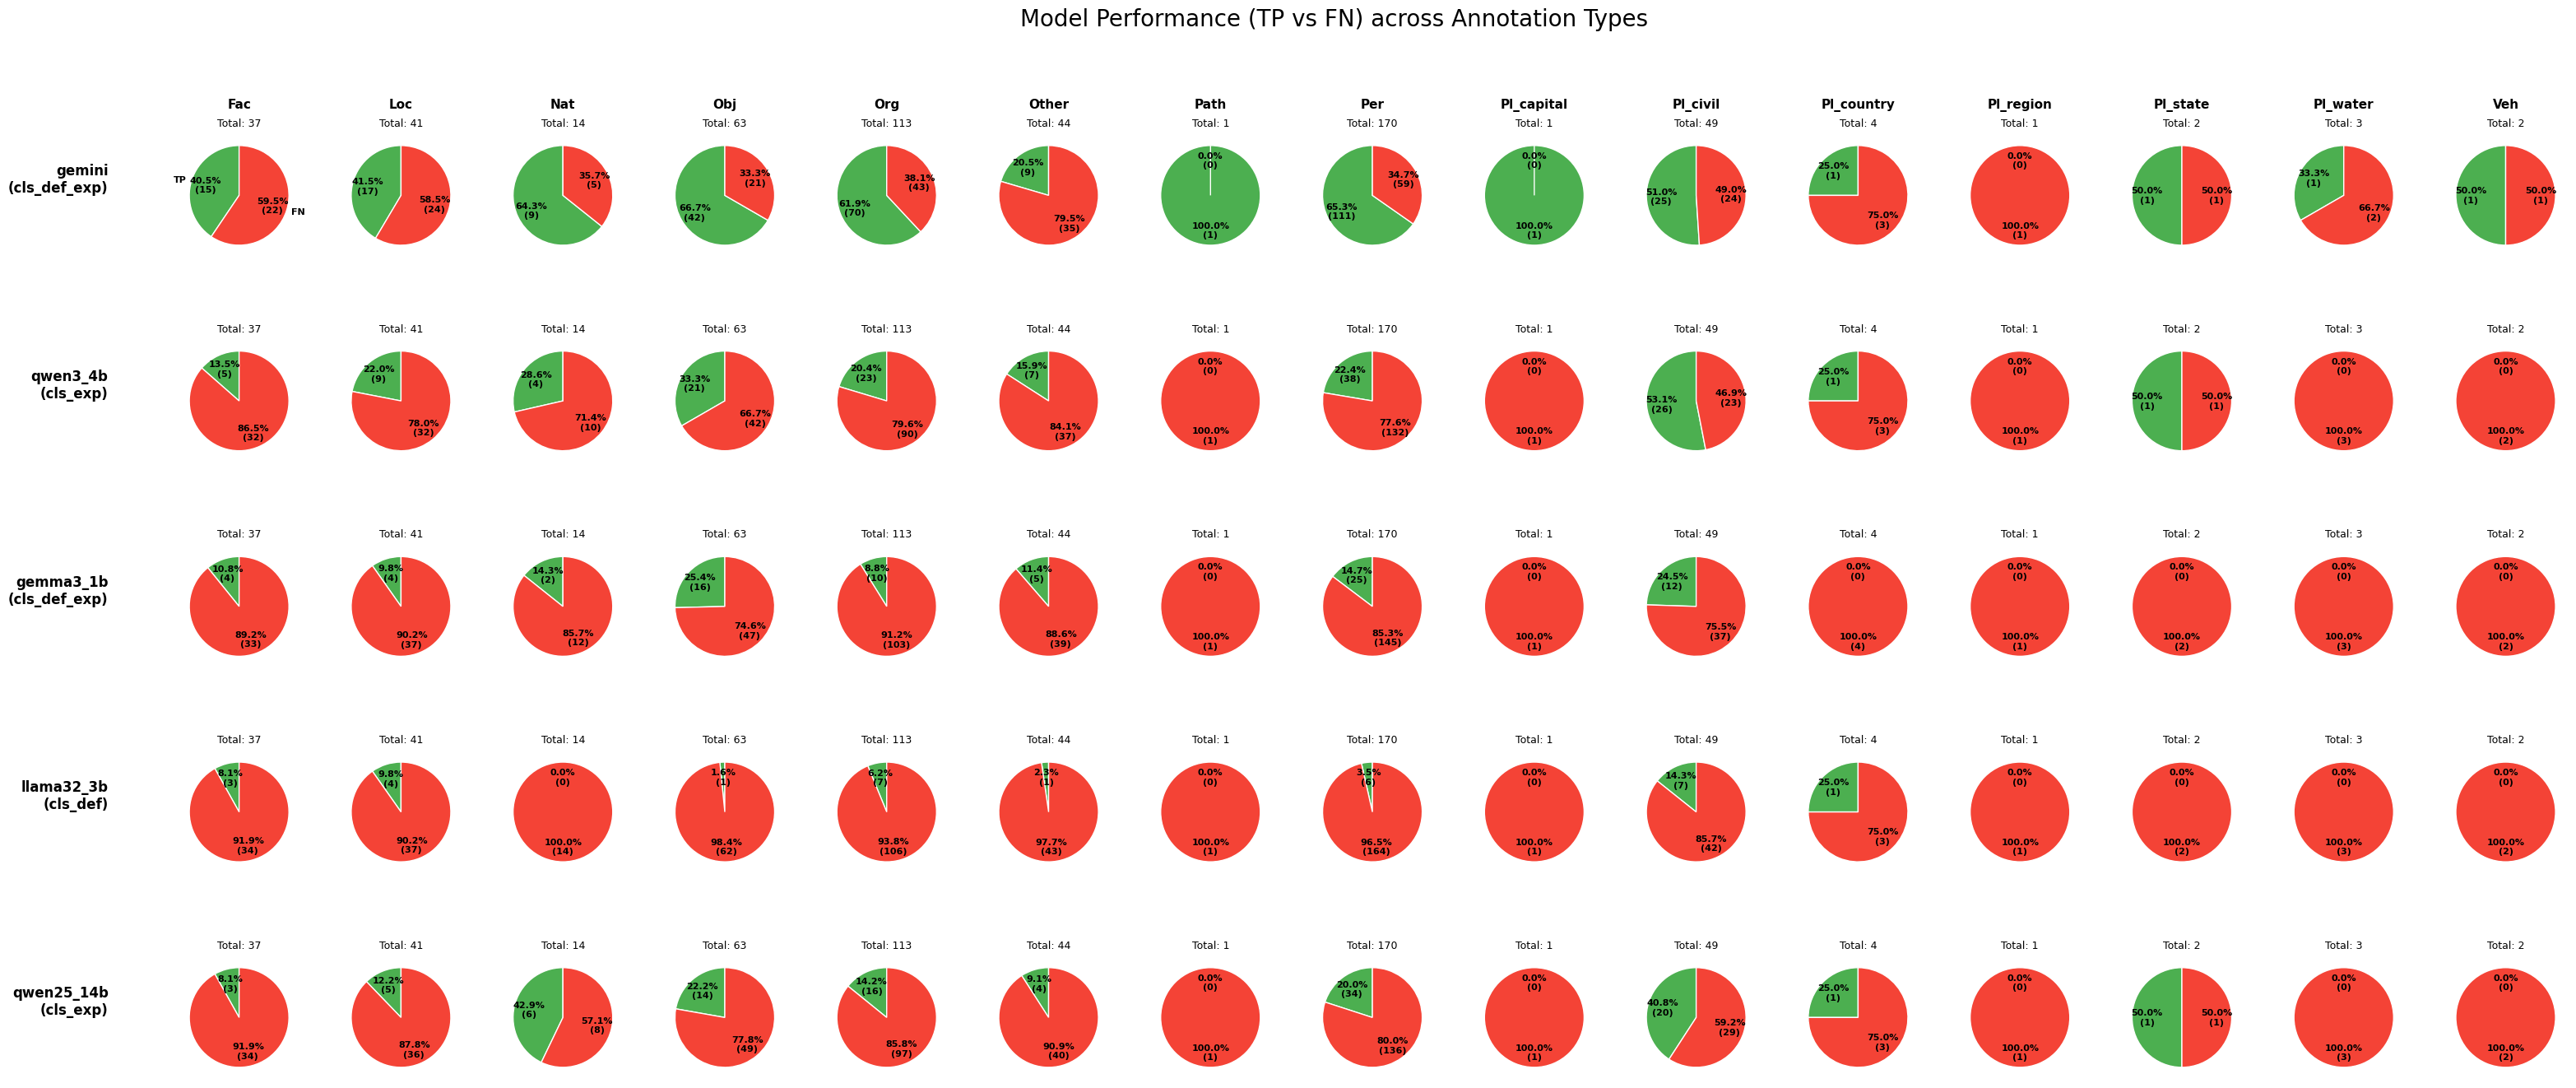

In [185]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "cls_def_exp"),
    ("qwen3_4b", "cls_exp"),
    ("gemma3_1b", "cls_def_exp"),
    ("llama32_3b", "cls_def"),
    ("qwen25_14b", "cls_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

#### English

In [186]:
raw_results_analysis =pd.read_csv("../results/prompt_selection/english/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_1,cls,GNR,Org,Org,tp,NaN
1,gemini,participants,lusa_1,cls,live music,NaN,Other,tp,NaN
2,gemini,participants,lusa_1,cls,drinking establishment,Fac,Fac,tp,NaN
3,gemini,participants,lusa_1,cls,location,Loc,Loc,tp,NaN
4,gemini,participants,lusa_1,cls,statement,Obj,Obj,tp,NaN


In [187]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,36,7
1,gemini,Fac,cls_def,36,6
2,gemini,Fac,cls_def_exp,36,18
3,gemini,Fac,cls_exp,36,19
4,gemini,Fac,ext,36,0
5,gemini,Fac,ext_def,36,0
6,gemini,Fac,ext_def_exp,36,19
7,gemini,Fac,ext_exp,36,18
8,gemini,Loc,cls,44,14
9,gemini,Loc,cls_def,44,13


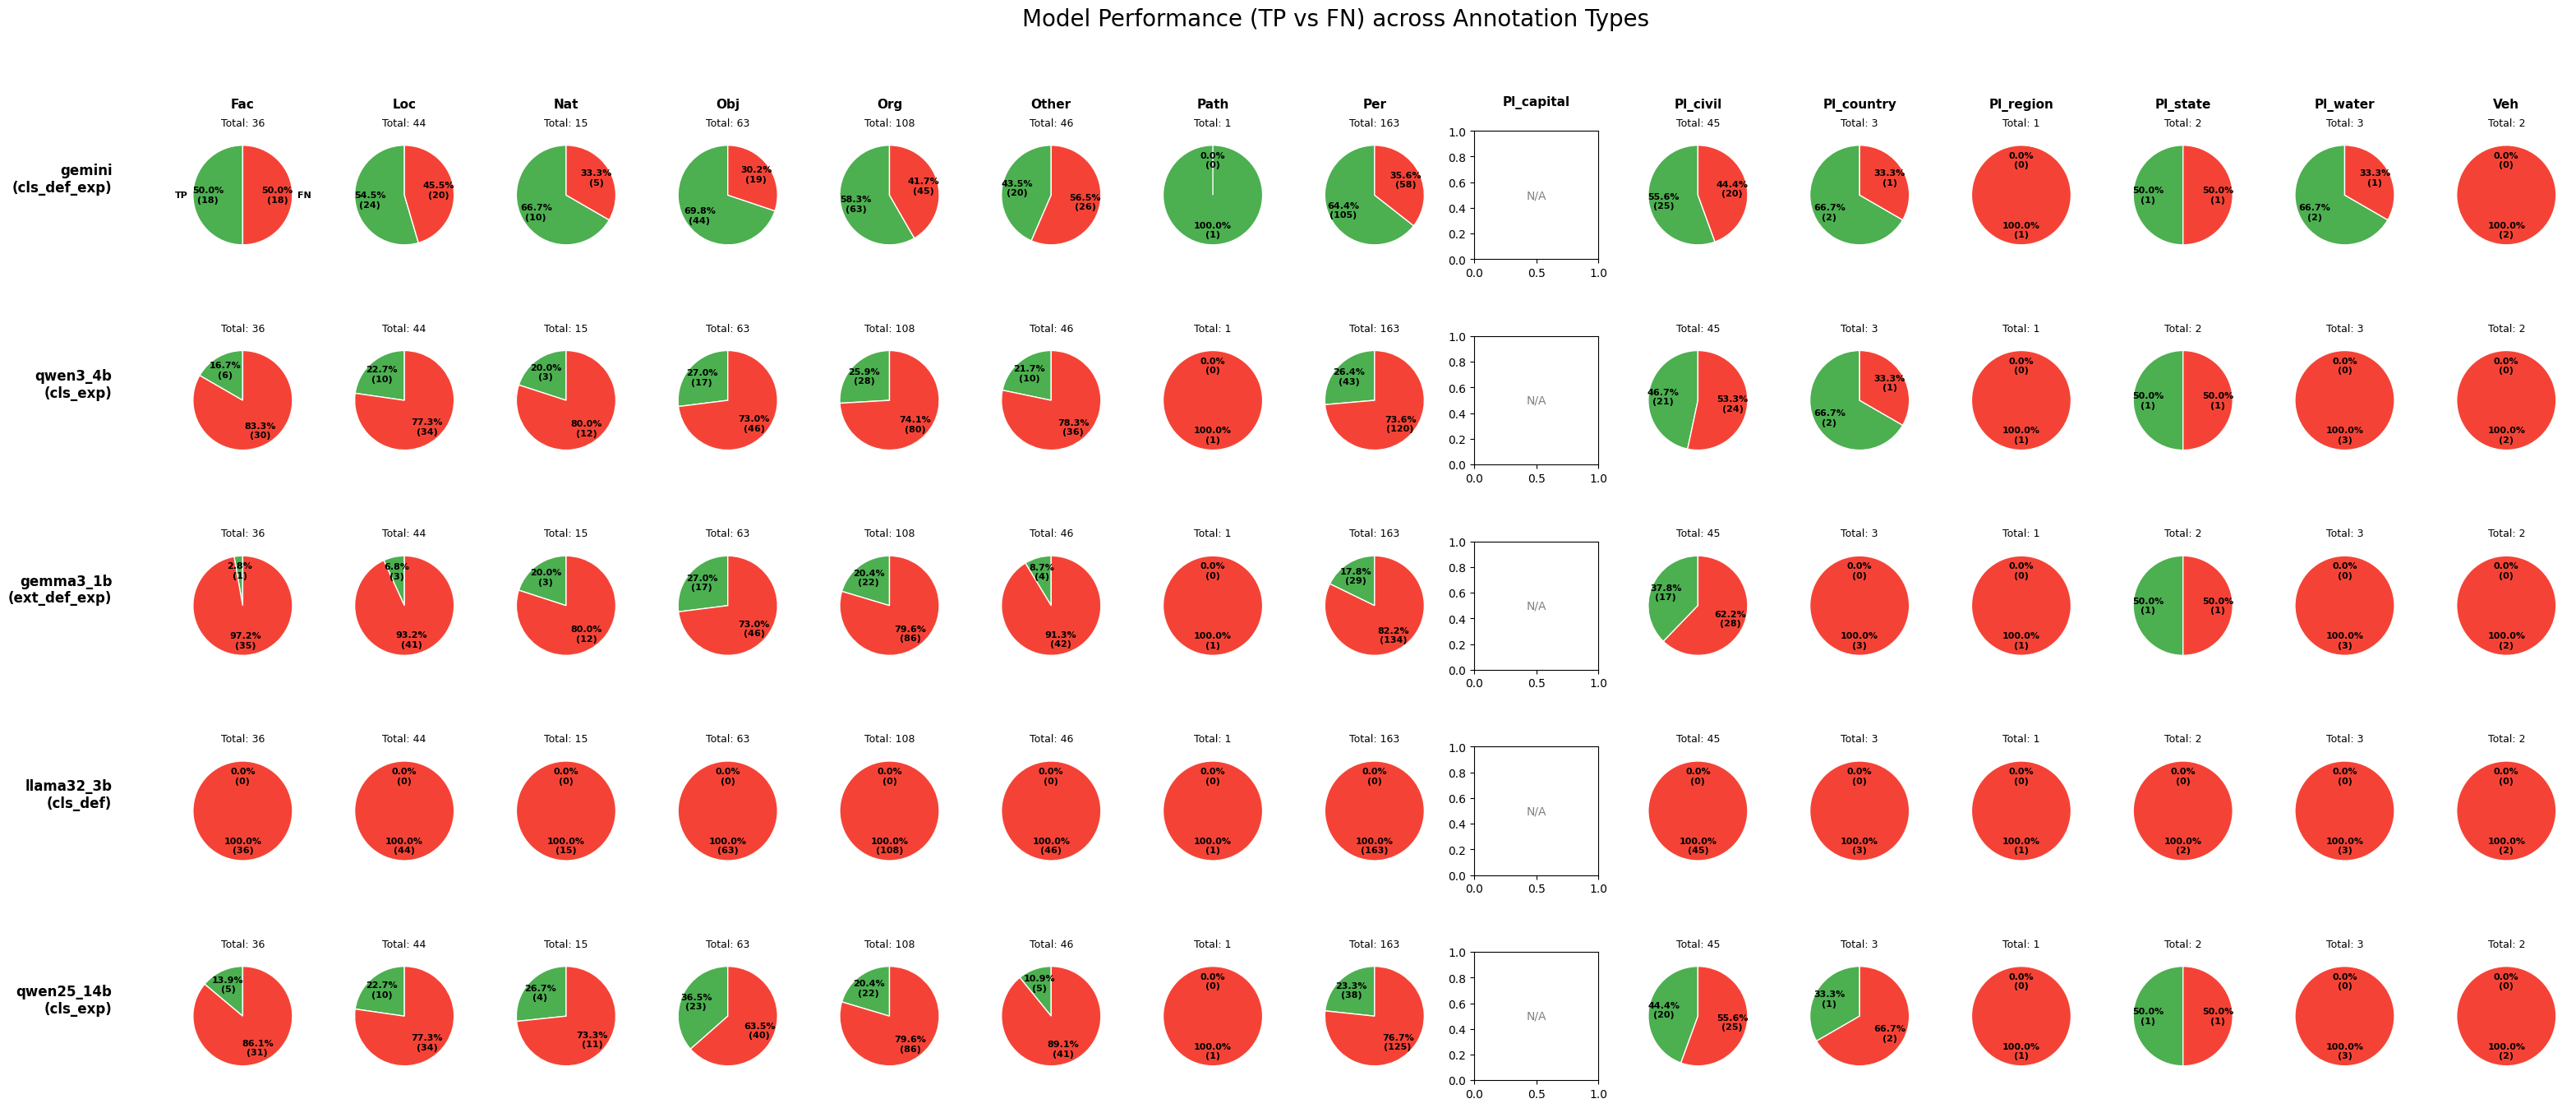

In [188]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "cls_def_exp"),
    ("qwen3_4b", "cls_exp"),
    ("gemma3_1b", "ext_def_exp"),
    ("llama32_3b", "cls_def"),
    ("qwen25_14b", "cls_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

### Relaxed Metrics Evaluate (Token level)

#### Portuguese

In [189]:
token_raw_results_analysis =pd.read_csv("../results/prompt_selection/portuguese/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_1,cls,['bar'],bar,Fac,bar,Fac,tp
1,gemini,participants,lusa_1,cls,['normas'],normas,Obj,nota,Obj,fp
2,gemini,participants,lusa_1,cls,['normas'],nota,Obj,nota,Obj,fn
3,gemini,participants,lusa_1,cls,['pessoas'],as,Per,as pessoas,Per,fn
4,gemini,participants,lusa_1,cls,['pessoas'],pessoas,Per,as pessoas,Per,tp


In [190]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,76,53
1,gemini,Fac,cls_def,72,49
2,gemini,Fac,cls_def_exp,104,84
3,gemini,Fac,cls_exp,99,81
4,gemini,Fac,ext,11,9
5,gemini,Fac,ext_def,23,18
6,gemini,Fac,ext_def_exp,97,79
7,gemini,Fac,ext_exp,102,86
8,gemini,Loc,cls,104,65
9,gemini,Loc,cls_def,73,54


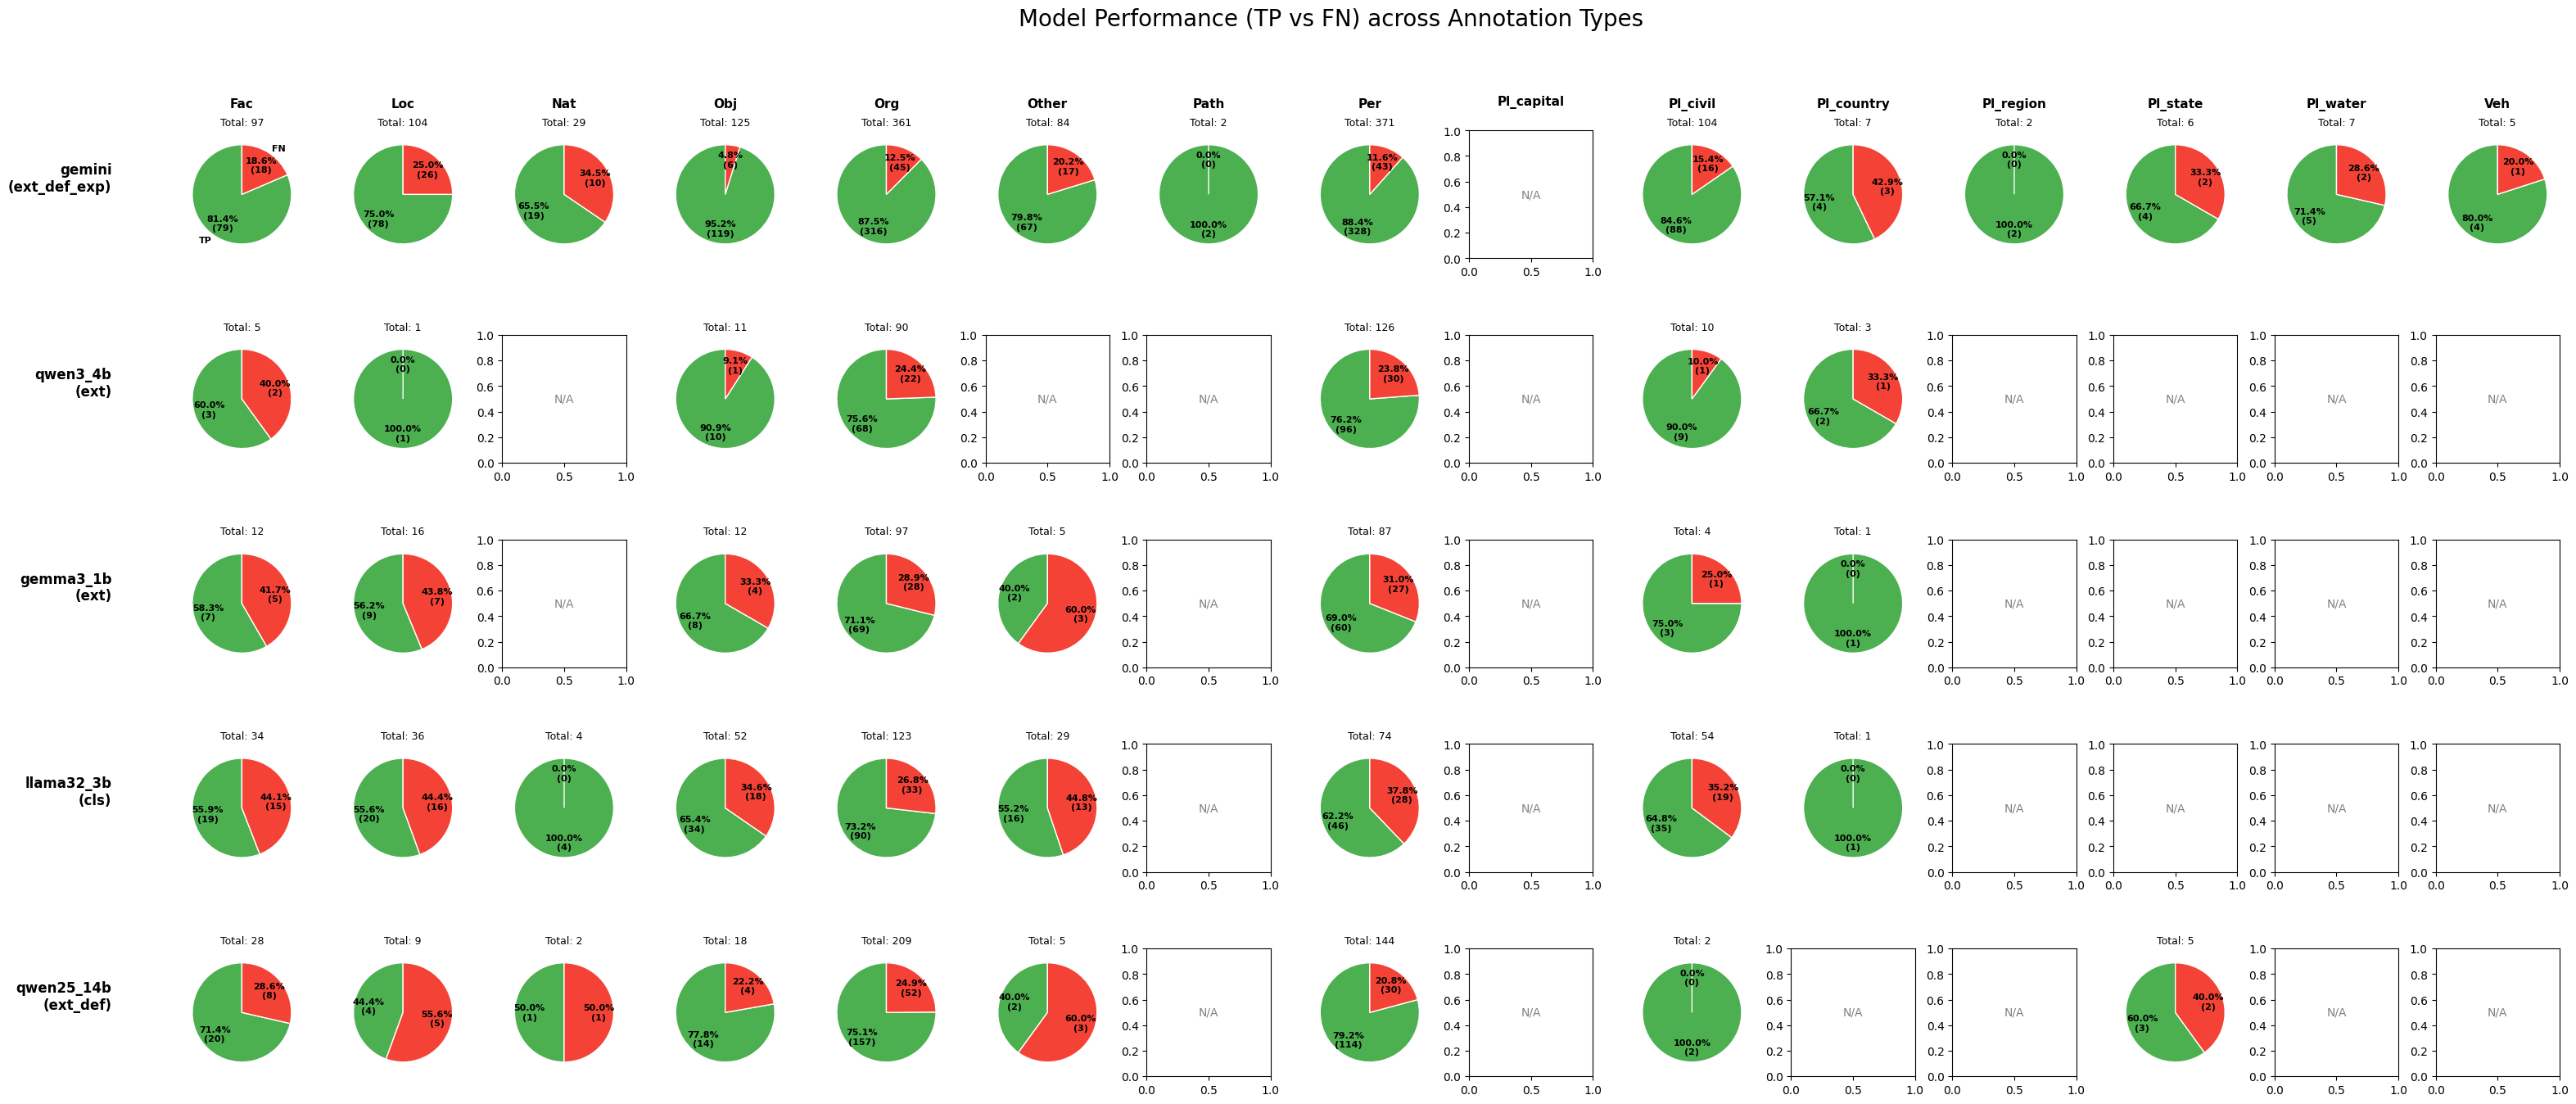

In [191]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "ext_def_exp"),
    ("qwen3_4b", "ext"),
    ("gemma3_1b", "ext"),
    ("llama32_3b", "cls"),
    ("qwen25_14b", "ext_def")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

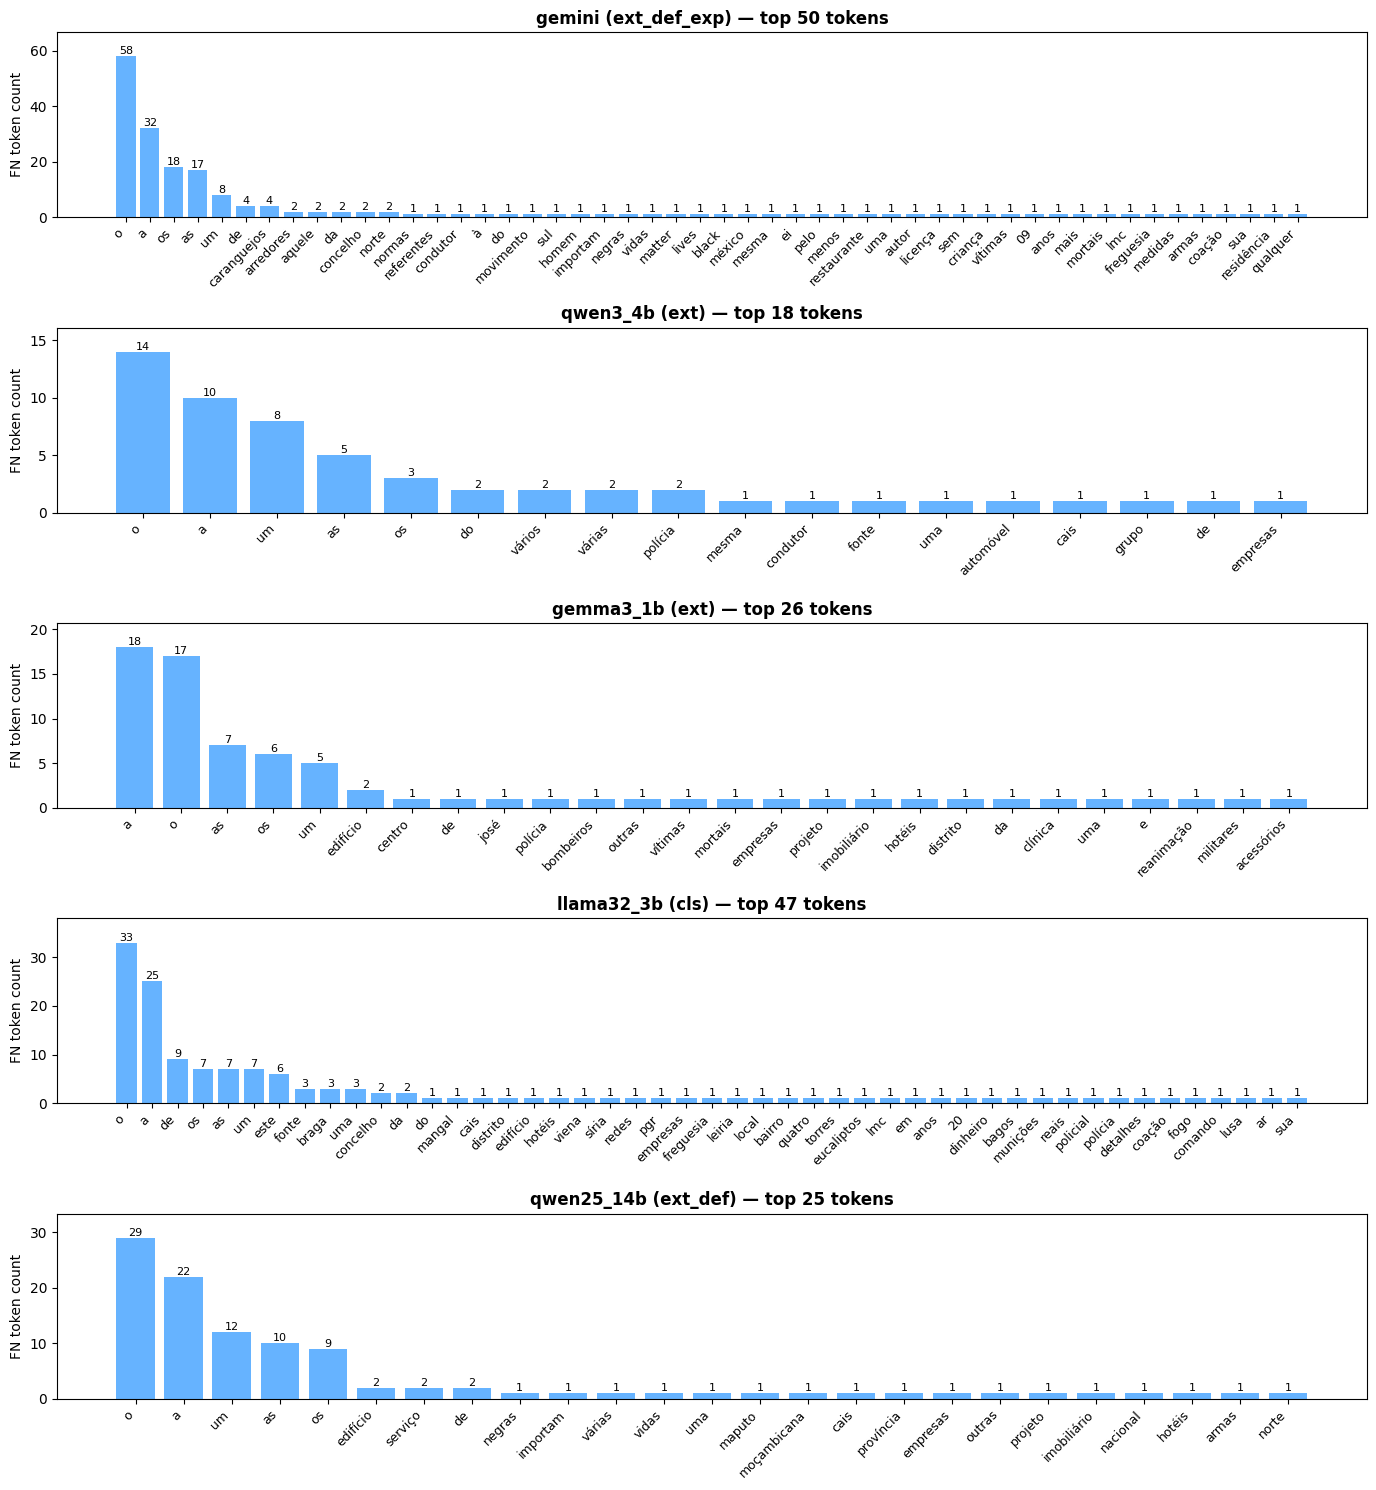

In [192]:
# Bar plot per target/model (token-level TP counts) ordered descending and annotated with counts
targets = [
    ("gemini", "ext_def_exp"),
    ("qwen3_4b", "ext"),
    ("gemma3_1b", "ext"),
    ("llama32_3b", "cls"),
    ("qwen25_14b", "ext_def")
]

top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'{modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### English

In [193]:
token_raw_results_analysis =pd.read_csv("../results/prompt_selection/english/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_1,cls,"['administrative', 'offense', 'notice']",an,Obj,an administrative offense notice,Obj,fn
1,gemini,participants,lusa_1,cls,"['administrative', 'offense', 'notice']",administrative,Obj,an administrative offense notice,Obj,tp
2,gemini,participants,lusa_1,cls,"['administrative', 'offense', 'notice']",offense,Obj,an administrative offense notice,Obj,tp
3,gemini,participants,lusa_1,cls,"['administrative', 'offense', 'notice']",notice,Obj,an administrative offense notice,Obj,tp
4,gemini,participants,lusa_1,cls,['soldiers'],soldiers,Per,soldiers,Per,tp


In [194]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,67,43
1,gemini,Fac,cls_def,50,33
2,gemini,Fac,cls_def_exp,86,68
3,gemini,Fac,cls_exp,84,70
4,gemini,Fac,ext,15,9
5,gemini,Fac,ext_def,15,11
6,gemini,Fac,ext_def_exp,84,70
7,gemini,Fac,ext_exp,83,68
8,gemini,Loc,cls,90,57
9,gemini,Loc,cls_def,73,49


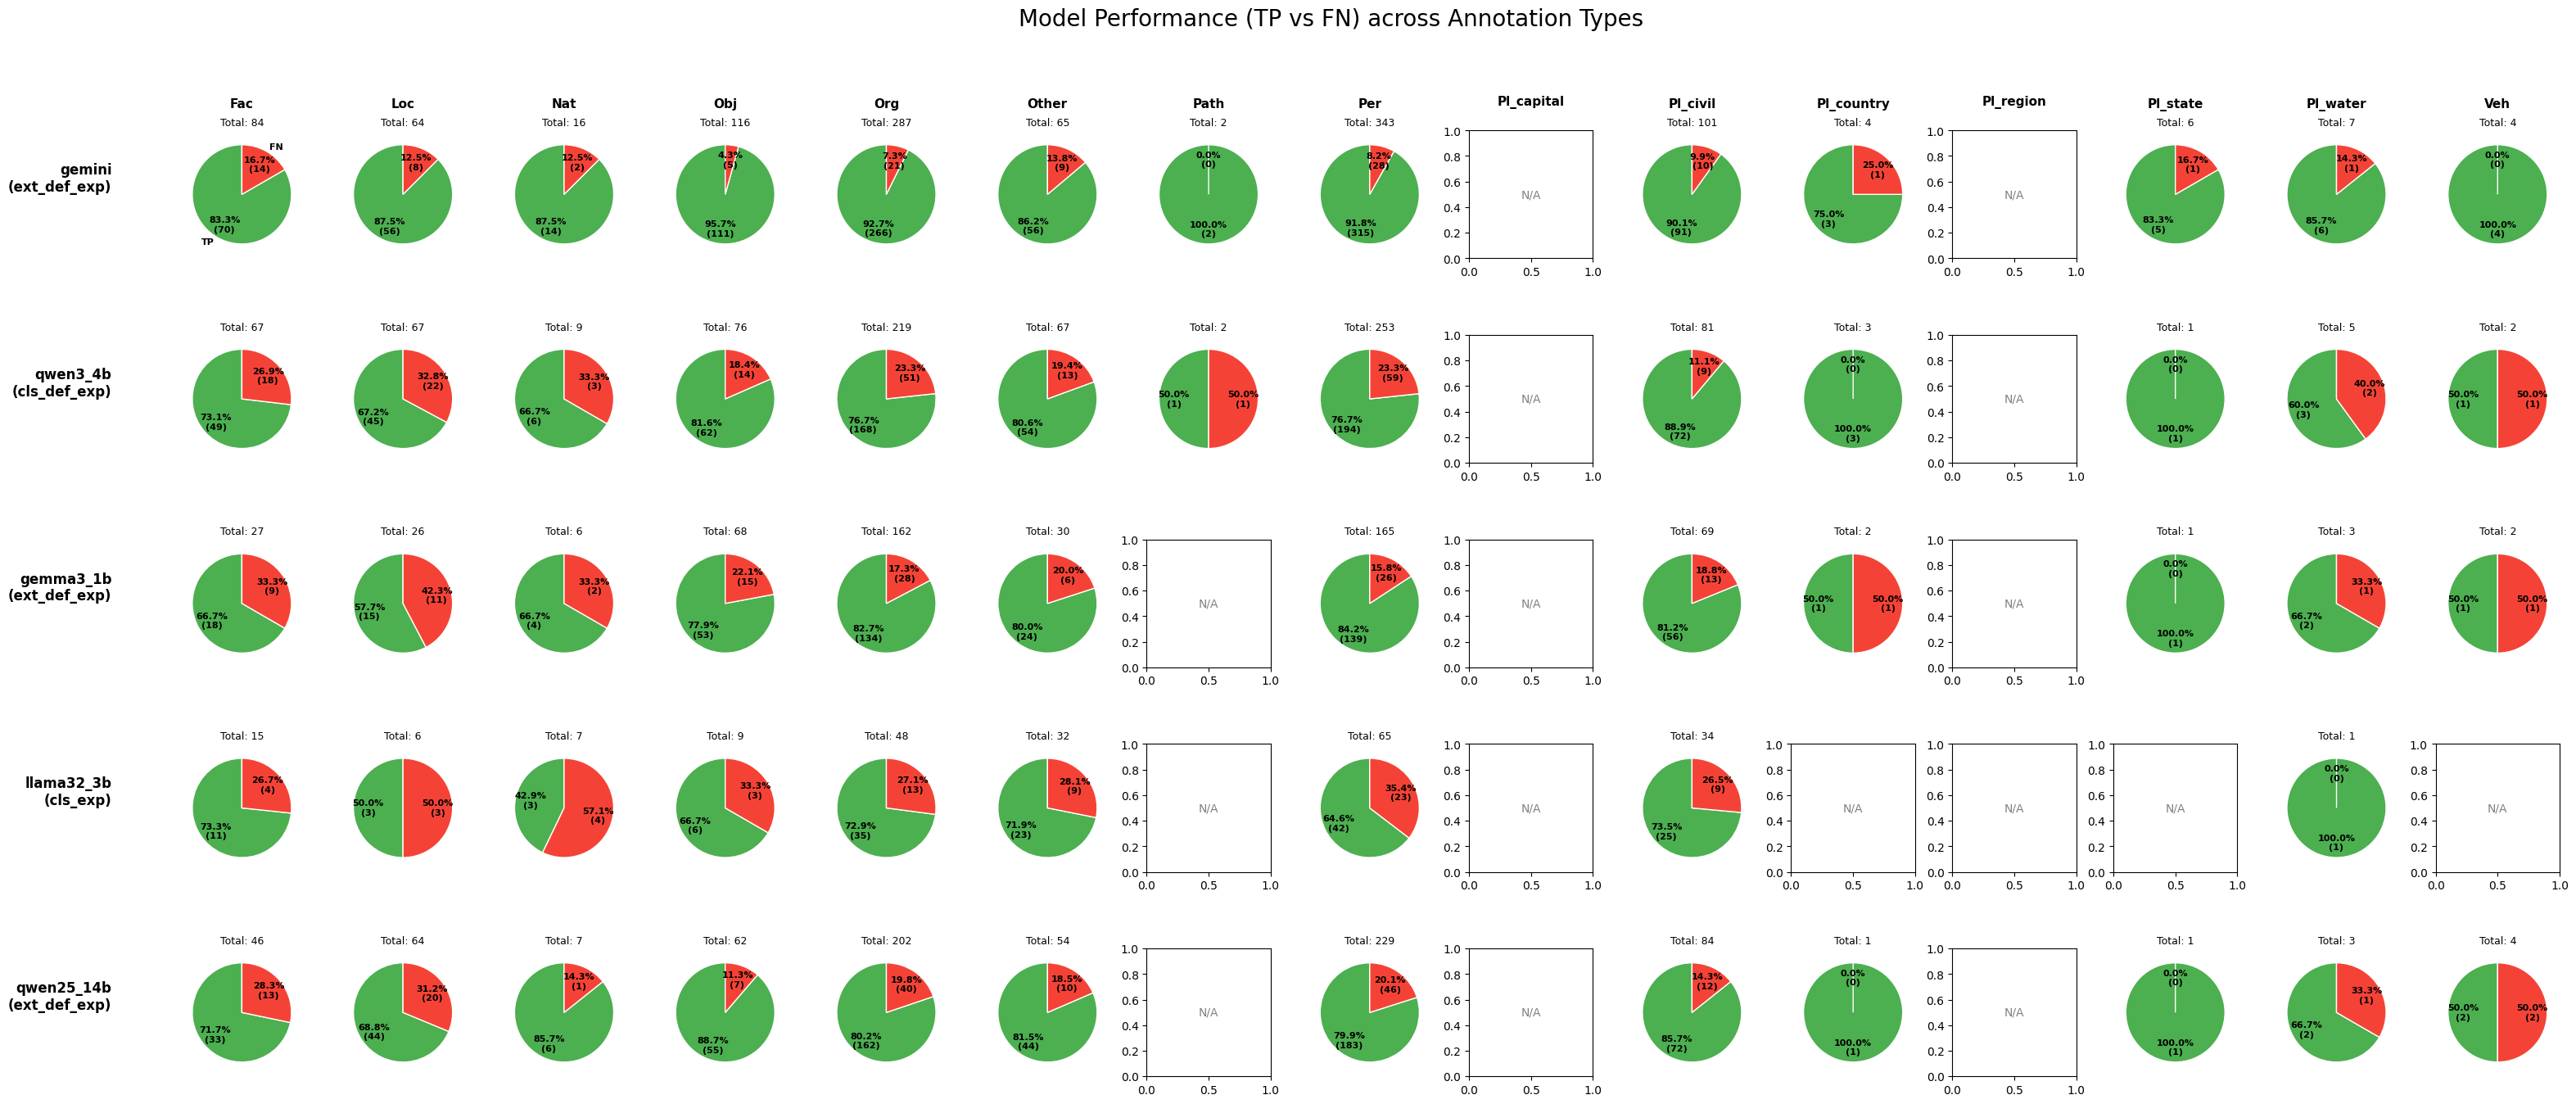

In [195]:
# 1. Define the BEST targets and annotation types
targets = [
    ("gemini", "ext_def_exp"),
    ("qwen3_4b", "cls_def_exp"),
    ("gemma3_1b", "ext_def_exp"),
    ("llama32_3b", "cls_exp"),
    ("qwen25_14b", "ext_def_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

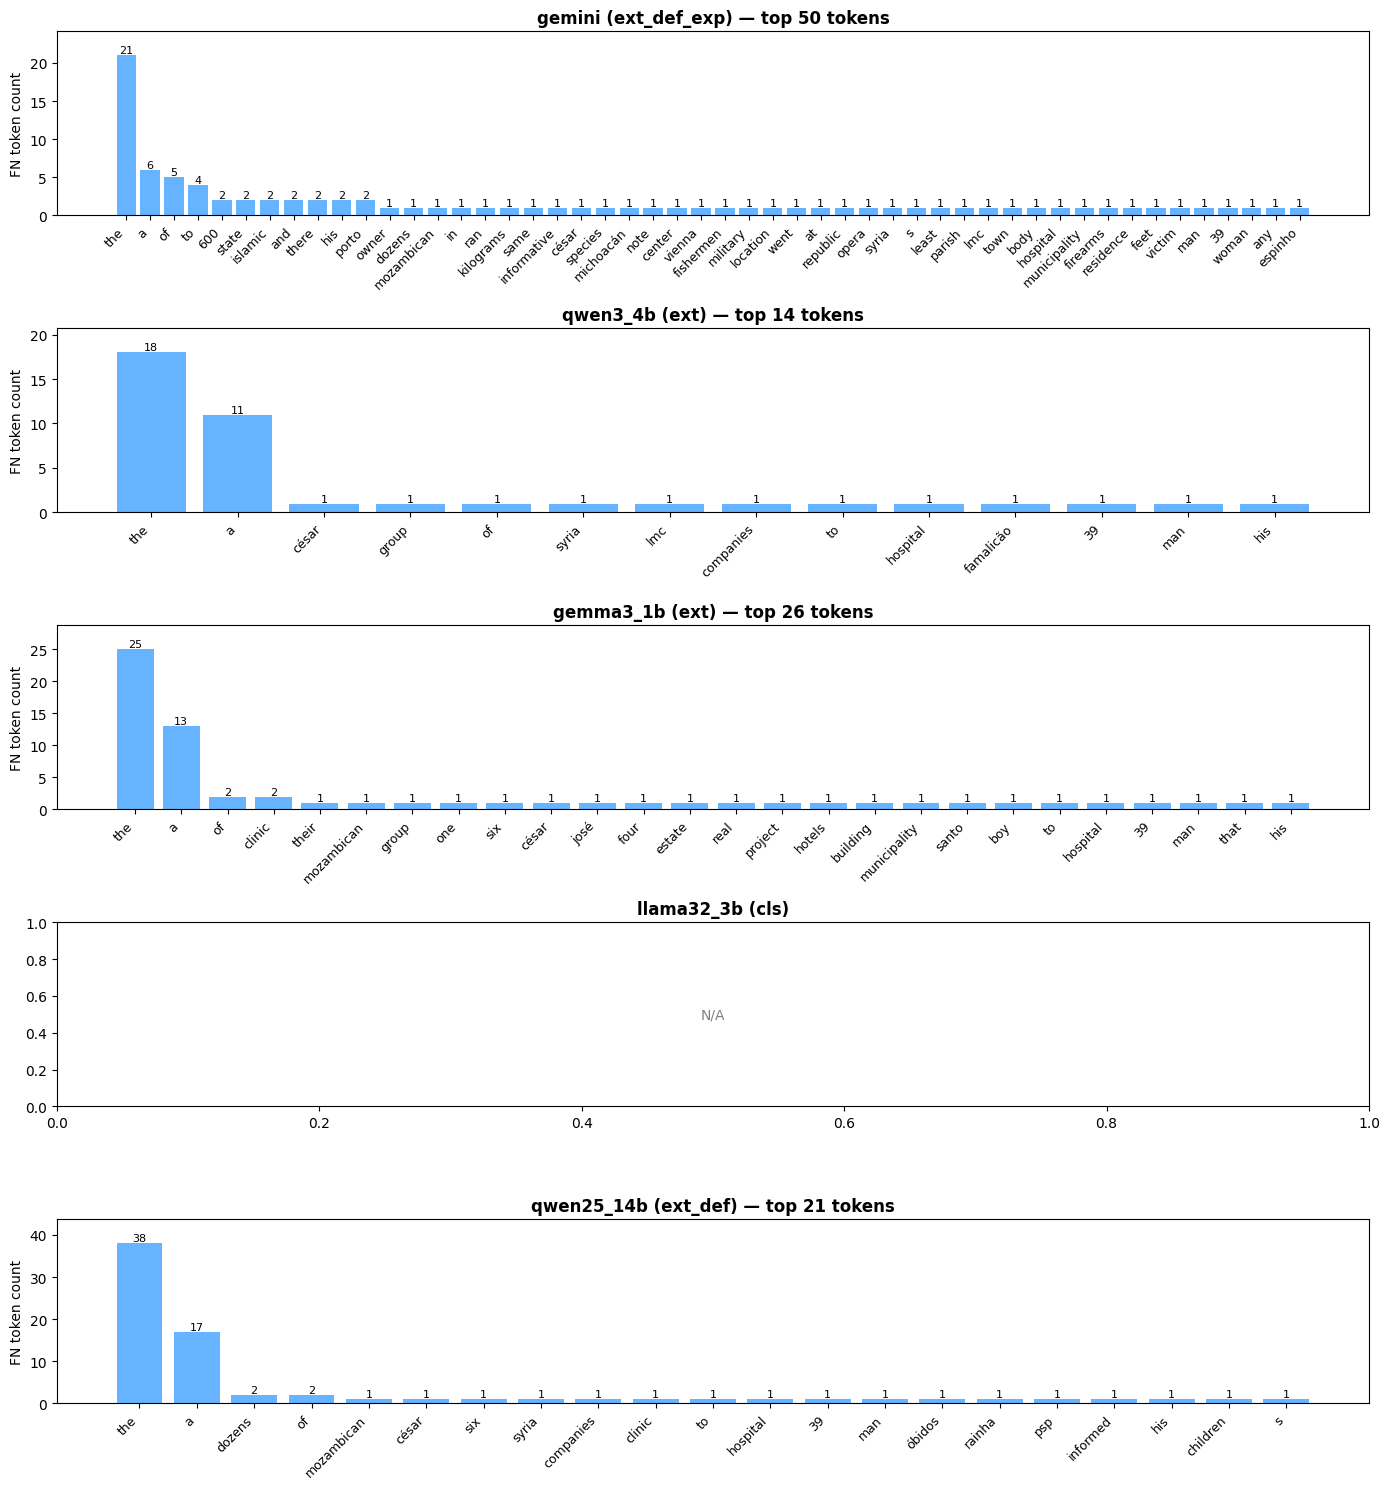

In [196]:
# Bar plot per target/model (token-level TP counts) ordered descending and annotated with counts
targets = [
    ("gemini", "ext_def_exp"),
    ("qwen3_4b", "ext"),
    ("gemma3_1b", "ext"),
    ("llama32_3b", "cls"),
    ("qwen25_14b", "ext_def")
]

top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'{modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## Test

### Strict Metrics Evaluate

#### Portuguese 

In [239]:
raw_results_analysis =pd.read_csv("../results/test/portuguese/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,llama32_3b,participants,lusa_31,cls_def,Covid-19,NaN,NaN,fp,NaN
1,llama32_3b,participants,lusa_31,cls_def,Restaurante que reunia 50 pessoas,Obj,NaN,fp,NaN
2,llama32_3b,participants,lusa_31,cls_def,GNR de Freamunde,Org,NaN,fp,NaN
3,llama32_3b,participants,lusa_31,cls_def,Autoridade,Org,NaN,fp,NaN
4,llama32_3b,participants,lusa_31,cls_def,Paços de Ferreira,Loc,NaN,fp,NaN


In [241]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,ext_exp
14,gemma3_1b,ext_exp
28,llama32_3b,cls_def
42,qwen25_14b,cls_exp
56,qwen3_4b,cls_exp


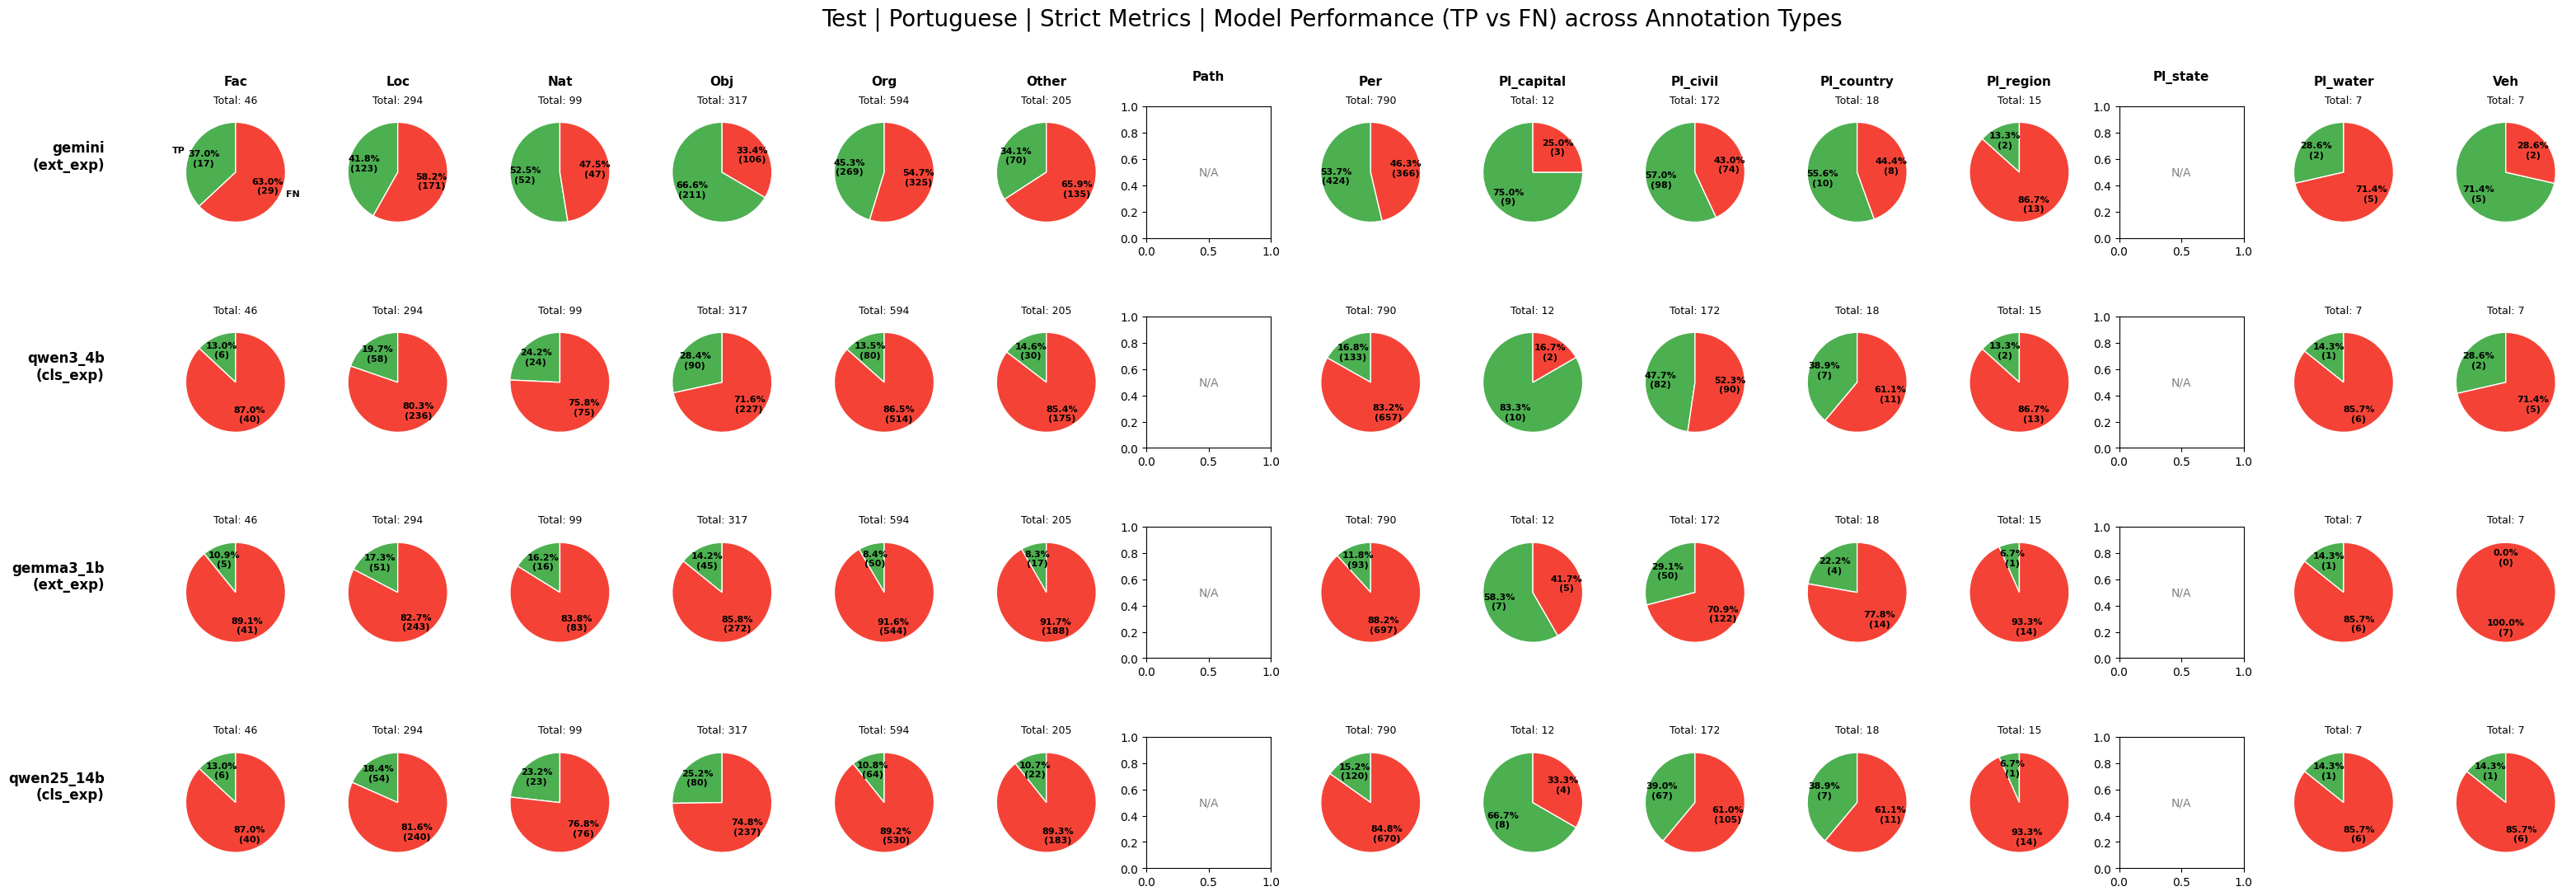

In [244]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "ext_exp"),
    ("qwen3_4b", "cls_exp"),
    ("gemma3_1b", "ext_exp"),
    ("qwen25_14b", "cls_exp")]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | Portuguese | Strict Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

#### English

In [230]:
raw_results_analysis =pd.read_csv("../results/test/english/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_100,cls_def_exp,security tapes,Obj,Obj,tp,NaN
1,gemini,participants,lusa_100,cls_def_exp,A 29-year-old man,Per,Per,tp,NaN
2,gemini,participants,lusa_100,cls_def_exp,police forces,Org,Org,tp,NaN
3,gemini,participants,lusa_100,cls_def_exp,the Lusa agency,Org,Org,tp,NaN
4,gemini,participants,lusa_100,cls_def_exp,the Lisbon Metropolitan Command (Cometlis),Org,Org,tp,NaN


In [231]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls_def_exp
14,gemma3_1b,ext_def_exp
28,qwen25_14b,ext_def_exp
42,qwen3_4b,cls_def_exp


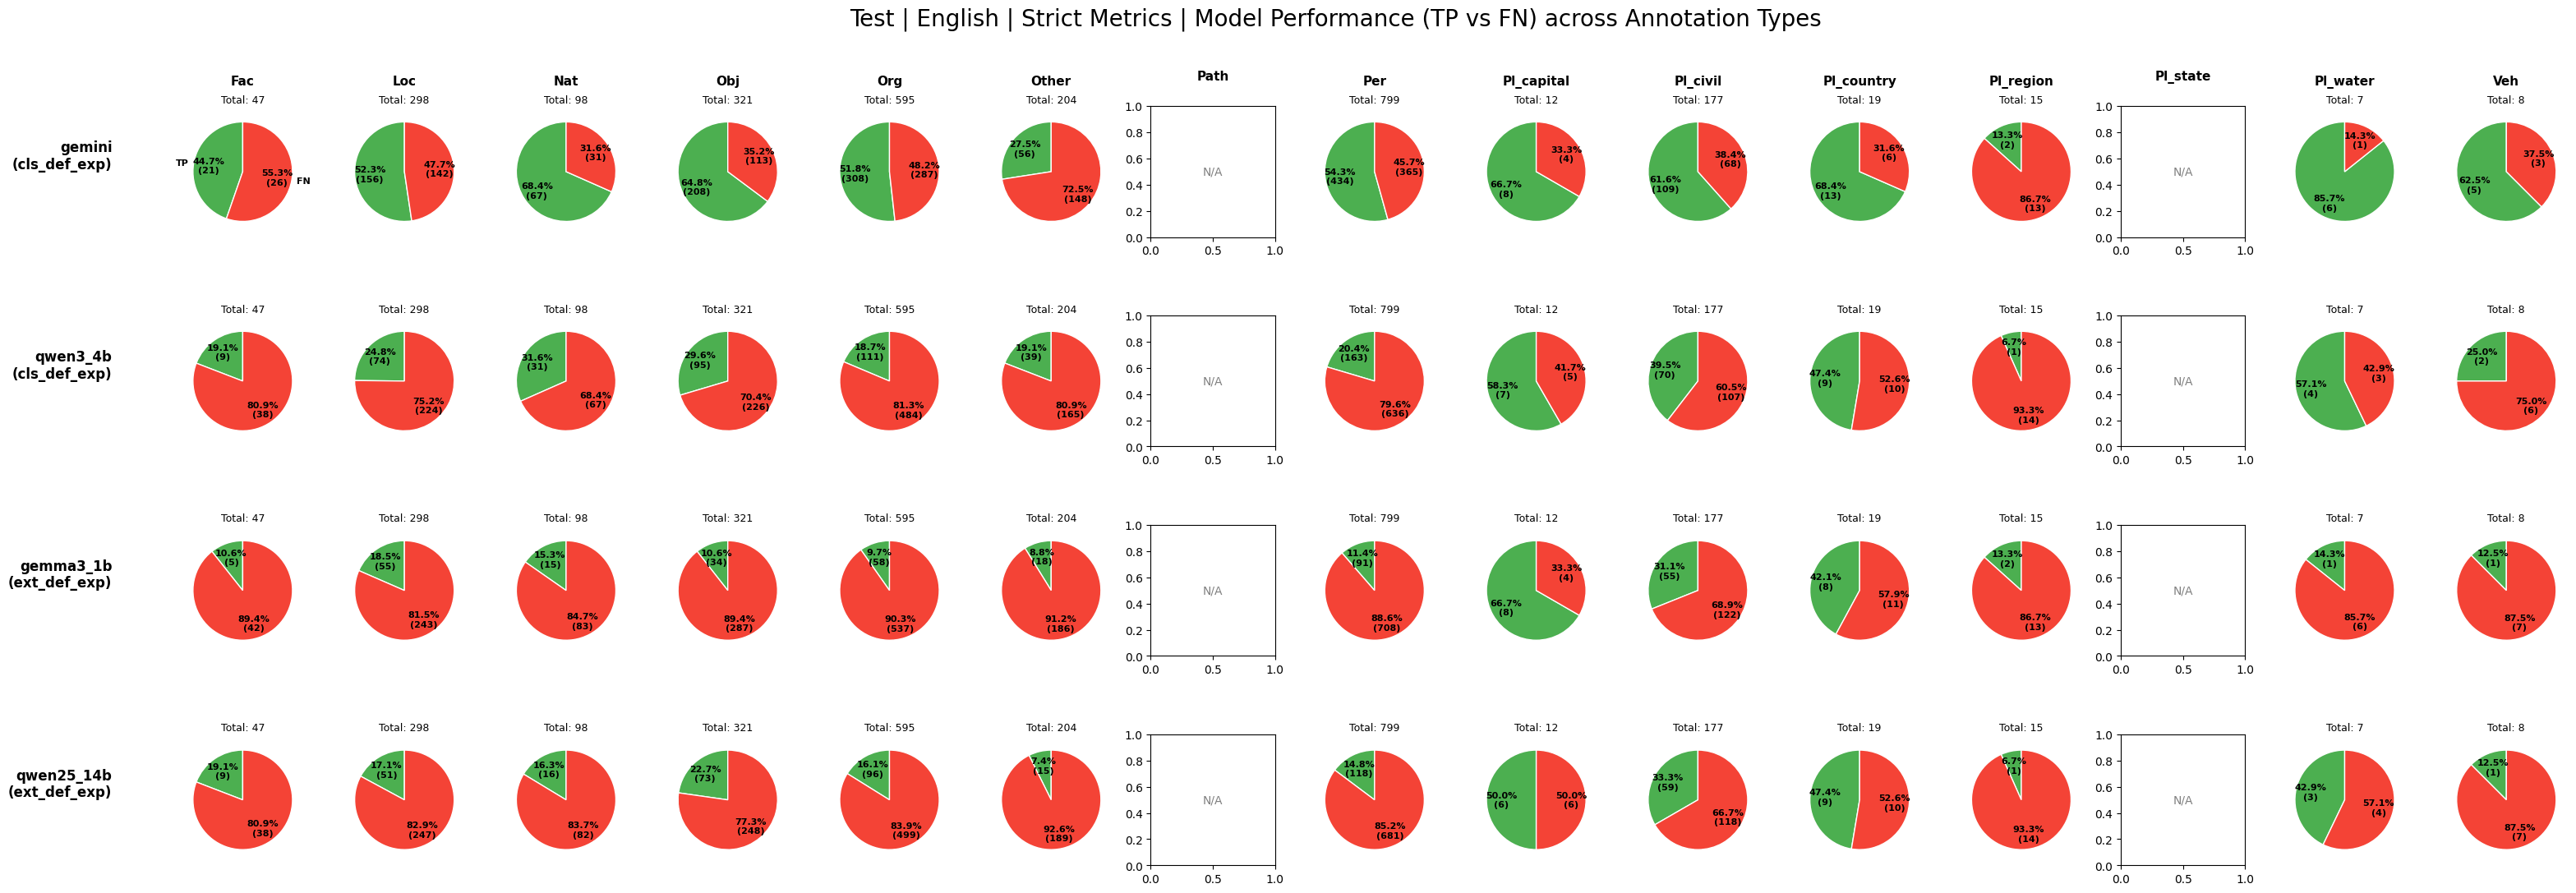

In [232]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "cls_def_exp"),
    ("qwen3_4b", "cls_def_exp"),
    ("gemma3_1b", "ext_def_exp"),
    ("qwen25_14b", "ext_def_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | English | Strict Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

### Relaxed Metrics Evaluate (Token level)

#### Portuguese

In [271]:
token_raw_results_analysis =pd.read_csv("../results/test/portuguese/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,llama32_3b,participants,lusa_31,cls_def,['fiscalização'],fiscalização,Other,NaN,NaN,fp
1,llama32_3b,participants,lusa_31,cls_def,['autoridade'],a,Org,a autoridade,Org,fn
2,llama32_3b,participants,lusa_31,cls_def,['autoridade'],autoridade,Org,a autoridade,Org,tp
3,llama32_3b,participants,lusa_31,cls_def,"['música', 'ao', 'vivo']",música,Other,música ao vivo,Other,tp
4,llama32_3b,participants,lusa_31,cls_def,"['música', 'ao', 'vivo']",ao,Other,música ao vivo,Other,tp


In [272]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,ext_exp
14,gemma3_1b,ext_exp
27,llama32_3b,cls_def
39,qwen25_14b,cls_exp
52,qwen3_4b,cls_exp


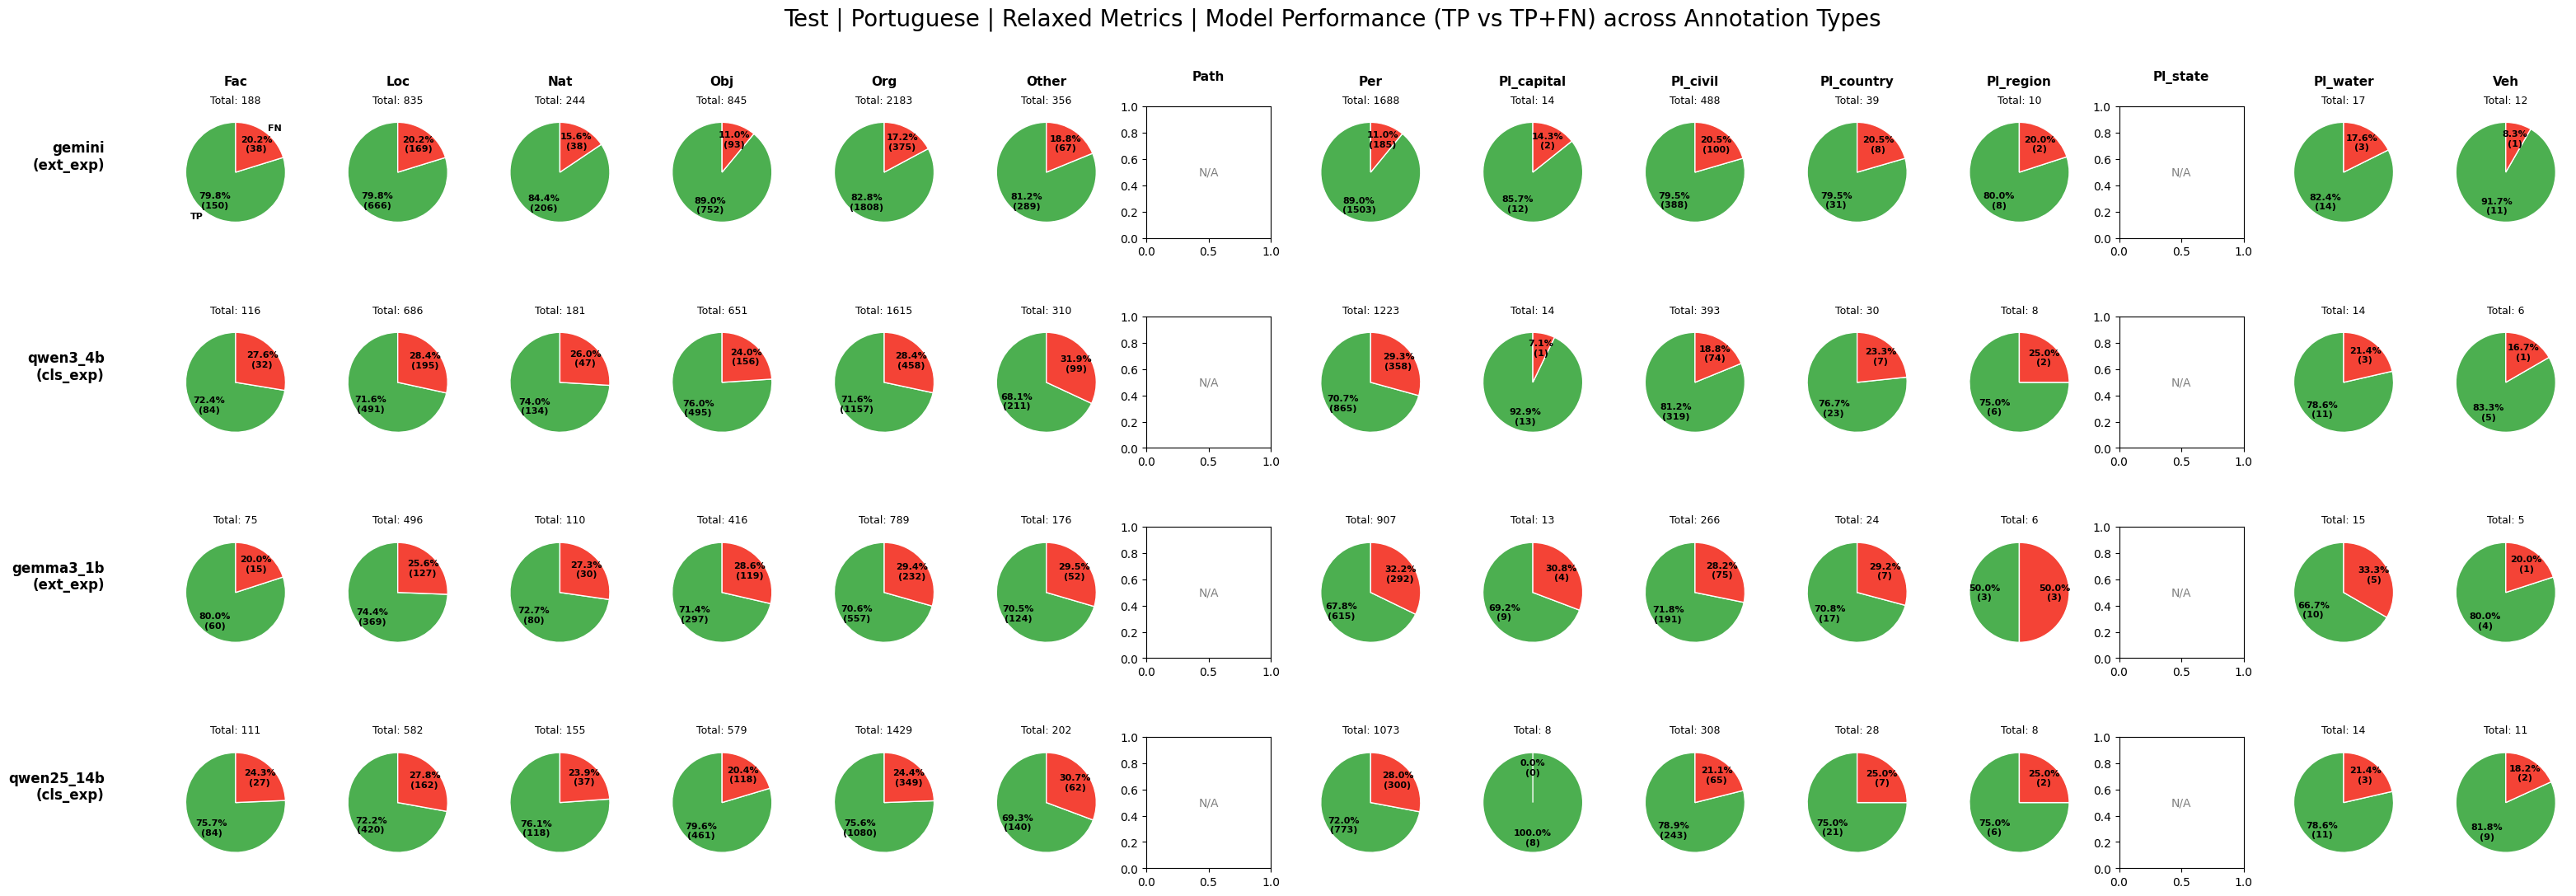

In [273]:
# 1. Define the targets and annotation types
targets = [
    ("gemini", "ext_exp"),
    ("qwen3_4b", "cls_exp"),
    ("gemma3_1b", "ext_exp"),
    ("qwen25_14b", "cls_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | Portuguese | Relaxed Metrics | Model Performance (TP vs TP+FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

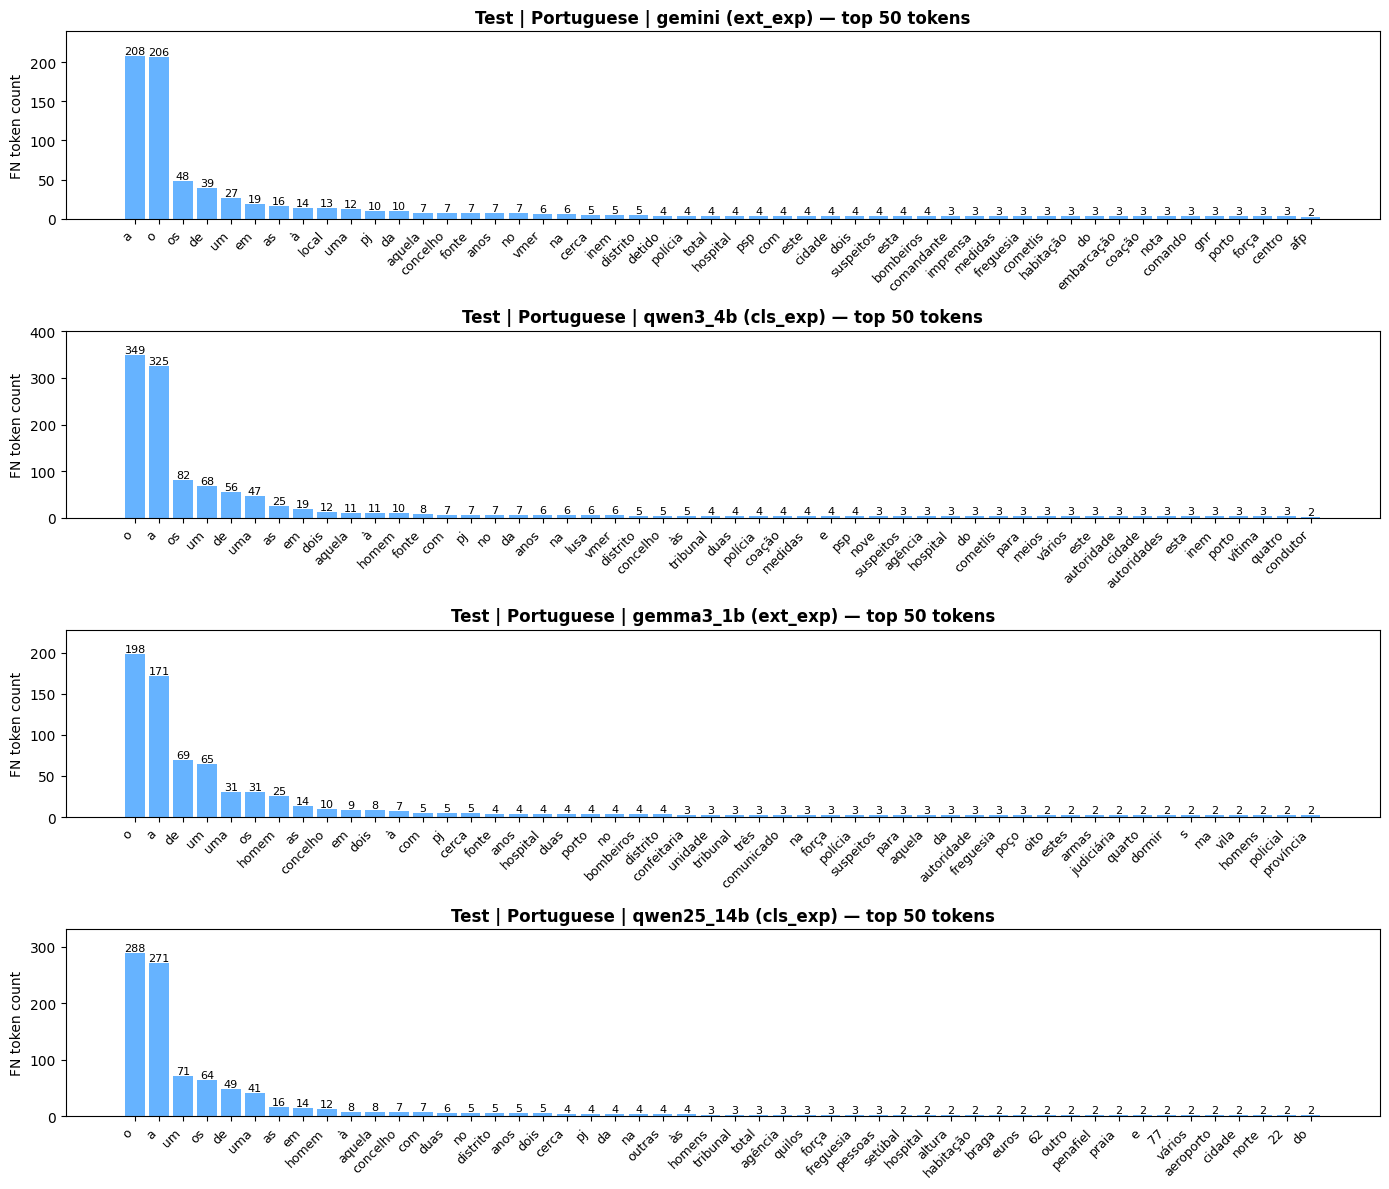

In [274]:
top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'Test | Portuguese | {modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### English

In [275]:
token_raw_results_analysis =pd.read_csv("../results/test/english/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_100,cls_def_exp,"['the', 'crime']",the,Other,the crime scene,Loc,tp
1,gemini,participants,lusa_100,cls_def_exp,"['the', 'crime']",crime,Other,the crime scene,Loc,tp
2,gemini,participants,lusa_100,cls_def_exp,"['the', 'crime']",scene,Other,the crime scene,Loc,fn
3,gemini,participants,lusa_100,cls_def_exp,"['the', 'psp']",the,Org,the PSP,Org,tp
4,gemini,participants,lusa_100,cls_def_exp,"['the', 'psp']",psp,Org,the PSP,Org,tp


In [276]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls_def_exp
14,gemma3_1b,ext_def_exp
28,qwen25_14b,ext_def_exp
42,qwen3_4b,cls_def_exp


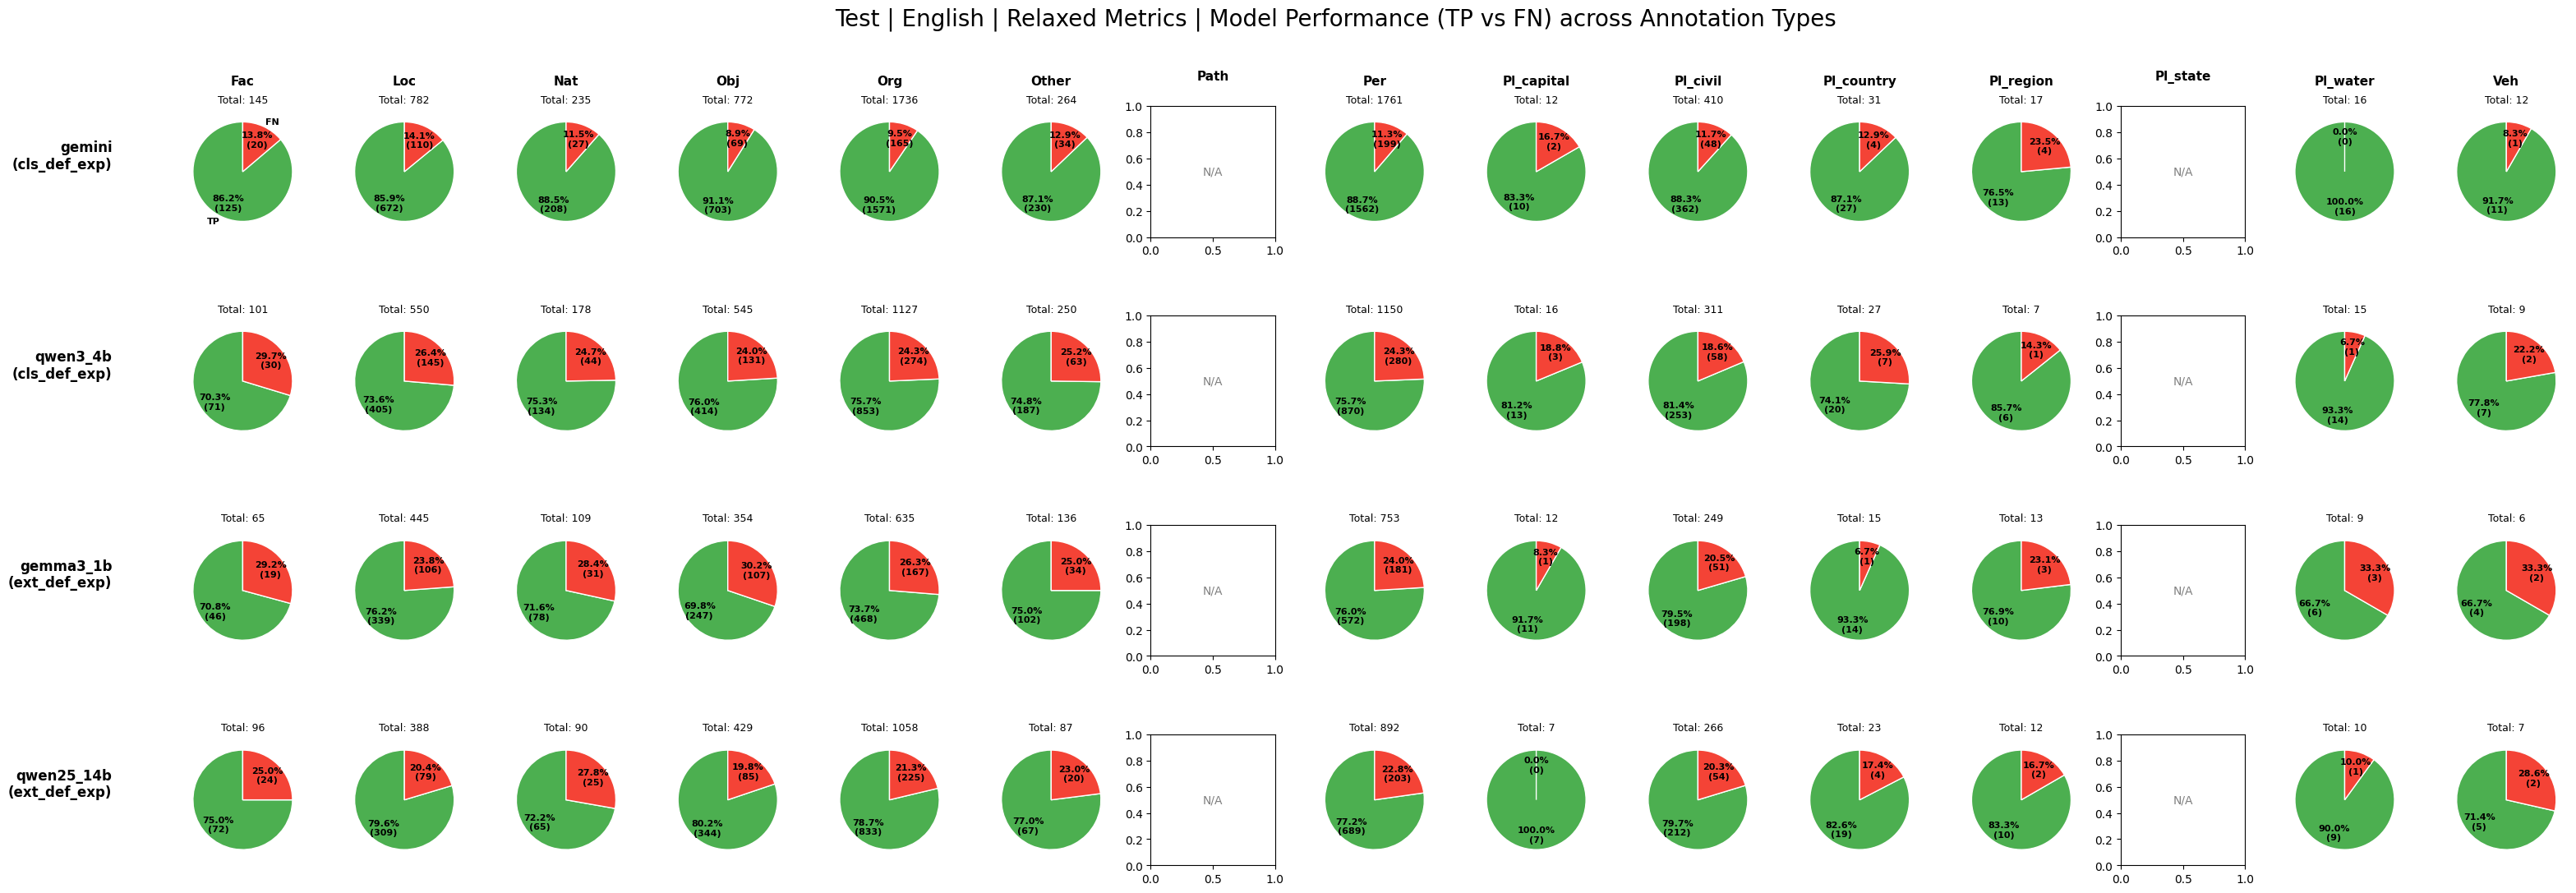

In [277]:
# 1. Define the BEST targets and annotation types
targets = [
    ("gemini", "cls_def_exp"),
    ("qwen3_4b", "cls_def_exp"),
    ("gemma3_1b", "ext_def_exp"),
    ("qwen25_14b", "ext_def_exp")
]

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | English | Relaxed Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

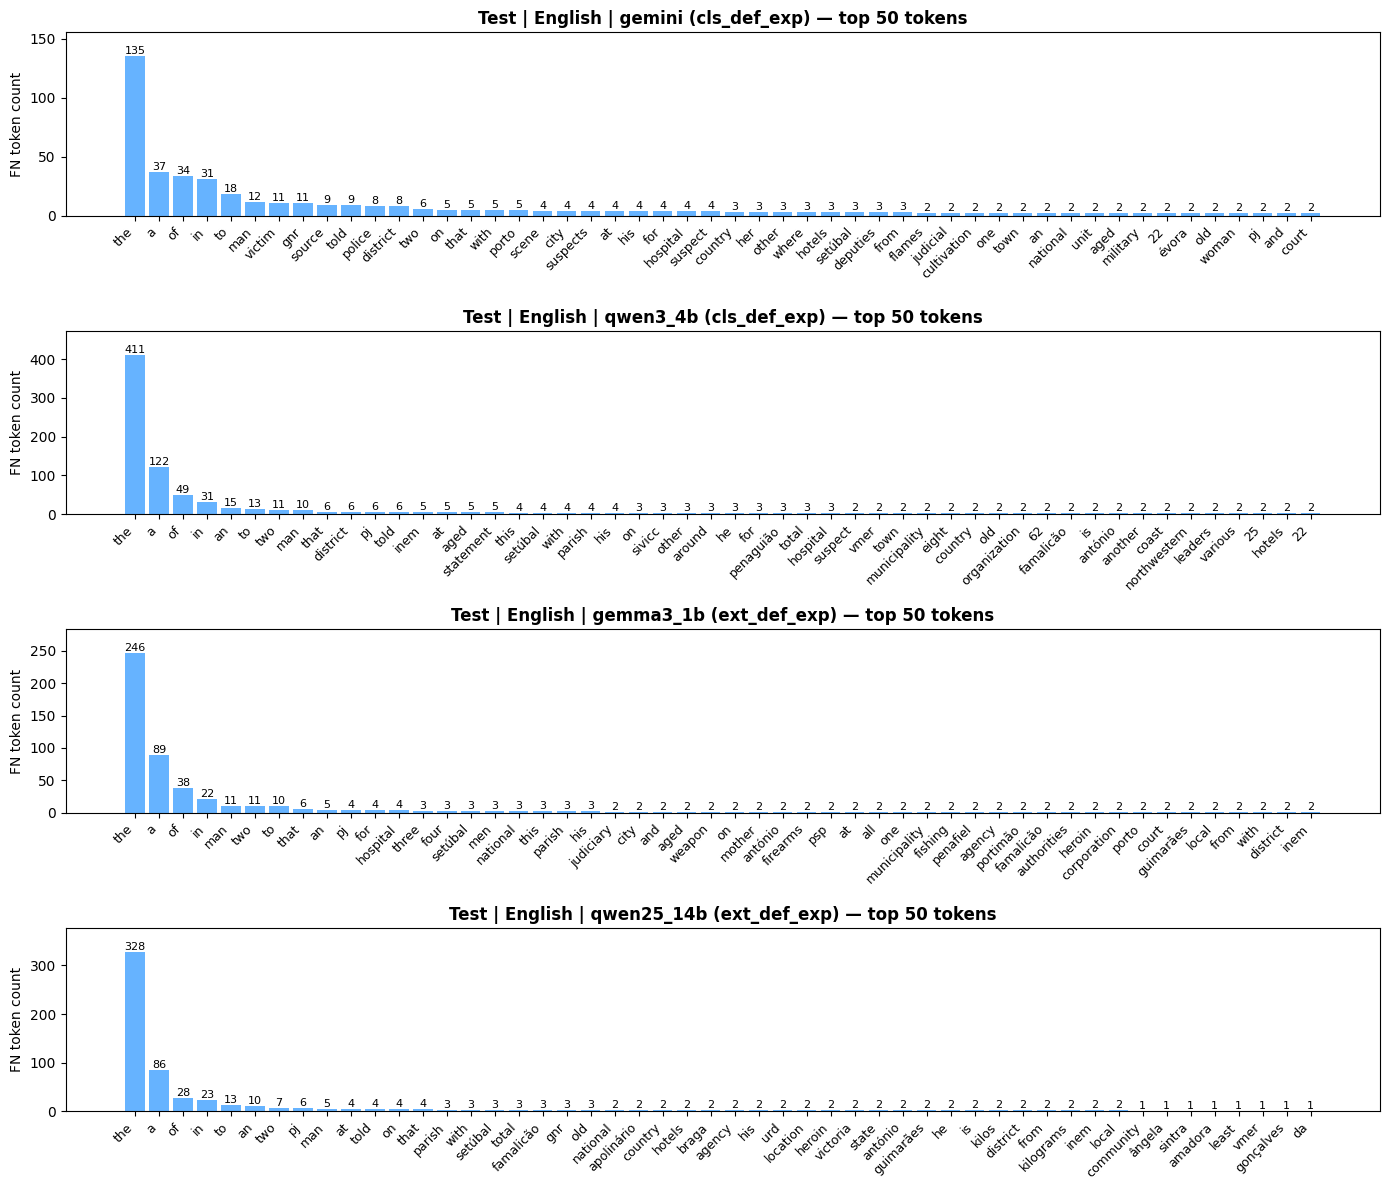

In [279]:
top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'Test | English | {modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
